# Programme de la gestion des frequence du reseau electrique

### Importation des packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
import seaborn as sns

# separation des variables
from sklearn.model_selection import train_test_split 
 
 
# Normalisation 
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

# MODELE DE PREDICTION
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,ElasticNetCV
# Evaluation du modele de prediction
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score


### Importation de la base de donnée

In [2]:
Delestage = pd.read_excel('Delestage_annuelle_2019.xlsx',parse_dates=True, index_col=[0])

Delestage.head()

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence (Hz)
Heure,,,,,,,
2019-01-01 01:00:00,636.930263,430.407707,0.0,0.0,0.0,0.0,50.109
2019-01-01 02:00:00,636.930263,406.129563,0.0,0.0,0.0,0.0,49.939
2019-01-01 03:00:00,636.930263,372.603857,0.0,0.0,0.0,0.0,50.281
2019-01-01 04:00:00,636.930263,356.614000,0.0,0.0,3.3,3.3,50.365
2019-01-01 05:00:00,636.930263,352.424888,0.0,0.0,0.0,0.0,50.199


###  Exploration

In [3]:
Delestage.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9774 entries, 2019-01-01 01:00:00 to 2020-02-12 06:00:00
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   P.dispo (MW)                   9774 non-null   float64
 1   Demande (MW)                   9774 non-null   float64
 2   Délest par Manque Product      9774 non-null   float64
 3   P. Effacée (MW)                9774 non-null   float64
 4   Autres         P. coupée (MW)  9774 non-null   float64
 5   Déficit total (MW)             9774 non-null   float64
 6   Frequence (Hz)                 7768 non-null   float64
dtypes: float64(7)
memory usage: 610.9 KB


In [4]:
Delestage.isnull().sum()

P.dispo (MW)                        0
Demande (MW)                        0
Délest par Manque Product           0
P. Effacée (MW)                     0
Autres         P. coupée (MW)       0
Déficit total (MW)                  0
Frequence (Hz)                   2006
dtype: int64

In [5]:
Delestage.isna().sum()

P.dispo (MW)                        0
Demande (MW)                        0
Délest par Manque Product           0
P. Effacée (MW)                     0
Autres         P. coupée (MW)       0
Déficit total (MW)                  0
Frequence (Hz)                   2006
dtype: int64

In [6]:
Delestage.describe()

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence (Hz)
count,9774.000000,9774.000000,9774.000000,9774.000000,9774.000000,9774.000000,7768.000000
mean,668.394144,496.591492,0.069879,0.189585,1.649501,1.908965,50.100678
std,66.462974,77.380186,1.466567,1.197528,4.537347,4.967570,0.236230
min,486.850000,284.344743,0.000000,0.000000,0.000000,0.000000,40.880000
25%,621.953083,438.883369,0.000000,0.000000,0.000000,0.000000,49.976000
50%,668.900000,500.357465,0.000000,0.000000,0.050000,0.060000,50.110000
75%,717.400000,555.596302,0.000000,0.000000,1.450000,1.800000,50.240000
max,857.010917,671.843713,62.140000,11.000000,106.900000,106.900000,50.961000


In [7]:
Delestage = Delestage.dropna()

In [8]:
Delestage.isnull().sum()

P.dispo (MW)                     0
Demande (MW)                     0
Délest par Manque Product        0
P. Effacée (MW)                  0
Autres         P. coupée (MW)    0
Déficit total (MW)               0
Frequence (Hz)                   0
dtype: int64

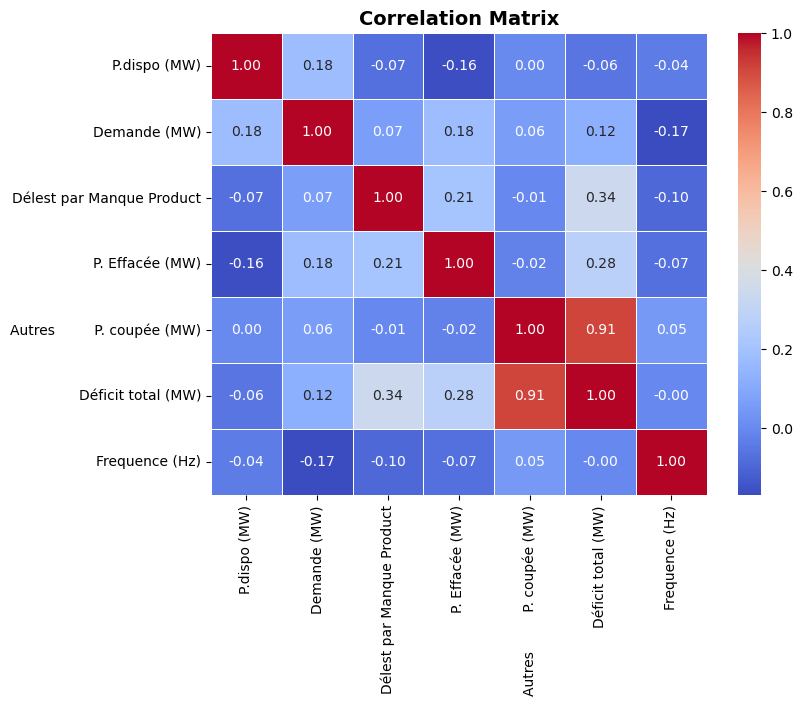

In [9]:
# Création du heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(Delestage.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Ajout d'un titre
plt.title("Correlation Matrix", fontsize=14, fontweight="bold")

# Affichage
plt.show()

#### VISUALISATION DES DONNEES ABERRANTES

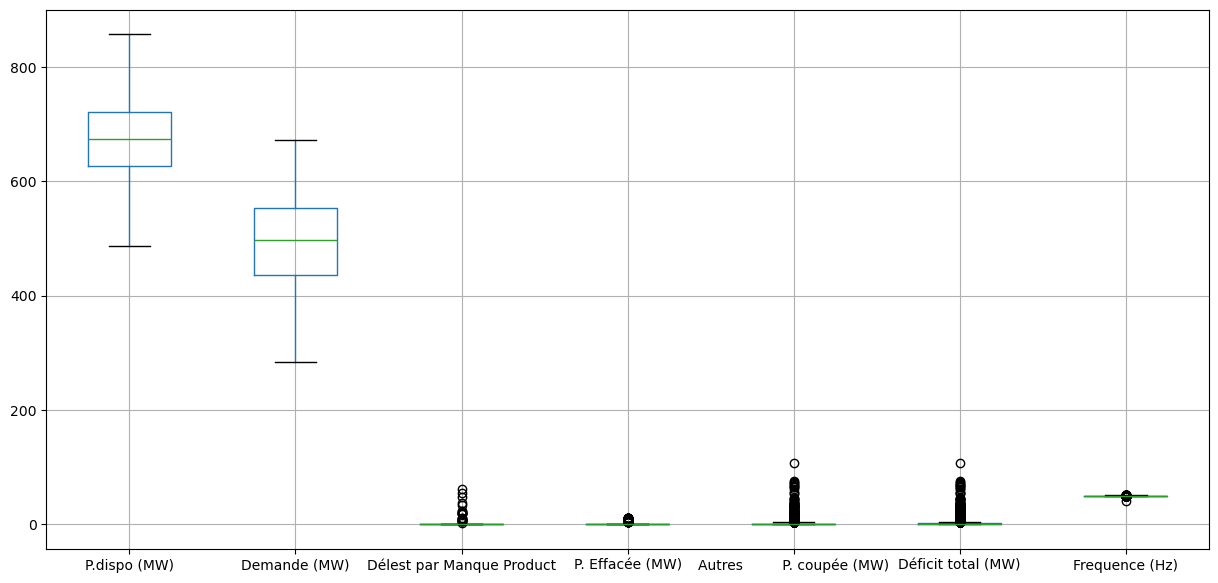

In [10]:
plt.figure(figsize=(15,7))
Delestage.boxplot()
plt.show()

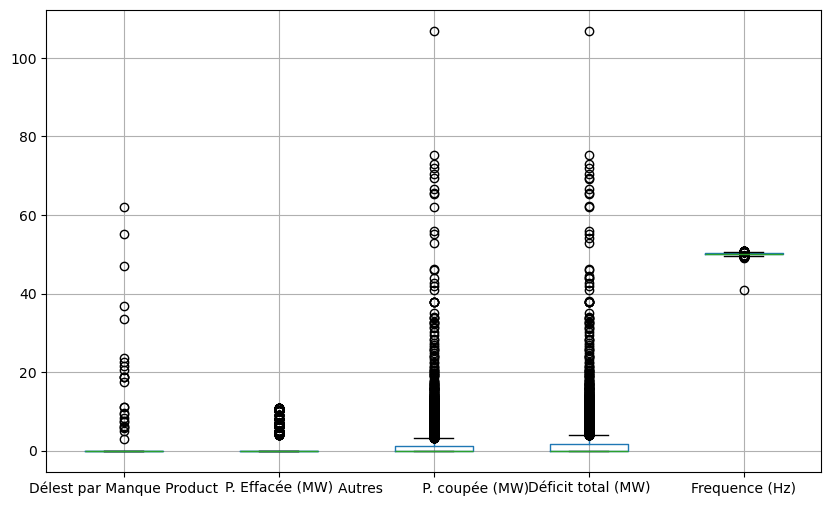

In [11]:
plt.figure(figsize=(10,6))
Delestage.drop(list(Delestage.columns[:2]),axis=1).boxplot()
plt.show()

In [12]:
# correction des valeurs aberrantes
liste_dictionaire ={}
for out in Delestage.columns:
    
    # Méthode IQR
    Q1 = Delestage[out].quantile(0.25)
    Q3 = Delestage[out].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    # Identifier les outliers
    outliers = Delestage[out][(Delestage[out] < borne_inf) | (Delestage[out]> borne_sup)]
    print(f"Valeurs aberrantes {out} = {len(outliers)}")
    listes = [x for x in Delestage[out] if borne_inf <= x <= borne_sup]
    liste_dictionaire[out] = listes
# Remplacer les outliers par la médiane
#revenus_corrigés = Delestage[out].apply(lambda x: Delestage[out].median() if x > borne_sup or x < borne_inf else x)


Valeurs aberrantes P.dispo (MW) = 0
Valeurs aberrantes Demande (MW) = 0
Valeurs aberrantes Délest par Manque Product = 25
Valeurs aberrantes P. Effacée (MW) = 178
Valeurs aberrantes Autres         P. coupée (MW) = 1128
Valeurs aberrantes Déficit total (MW) = 1101
Valeurs aberrantes Frequence (Hz) = 191


In [13]:
liste_dictionaire.keys()

dict_keys(['P.dispo (MW)', 'Demande (MW)', 'Délest par Manque Product', 'P. Effacée (MW)', 'Autres         P. coupée (MW)', 'Déficit total (MW)', 'Frequence (Hz)'])

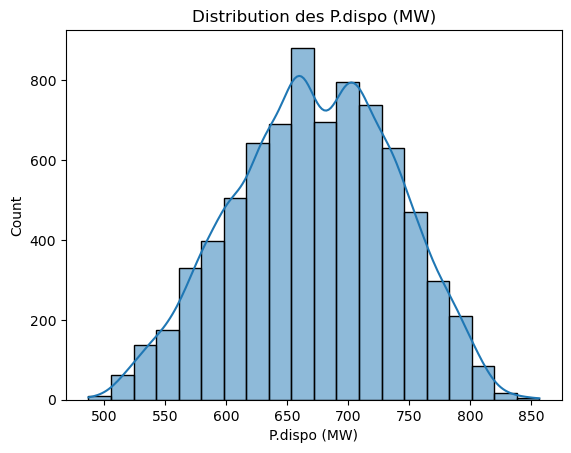

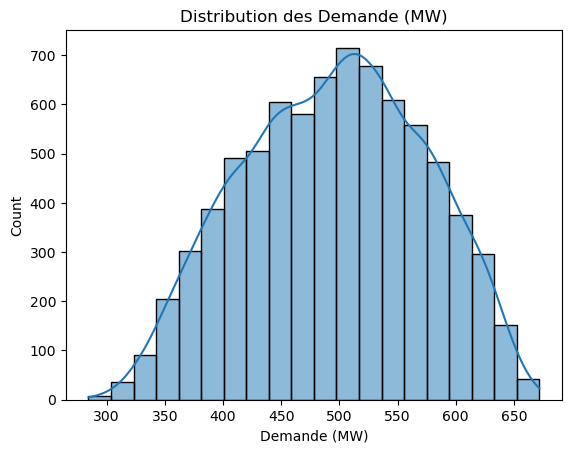

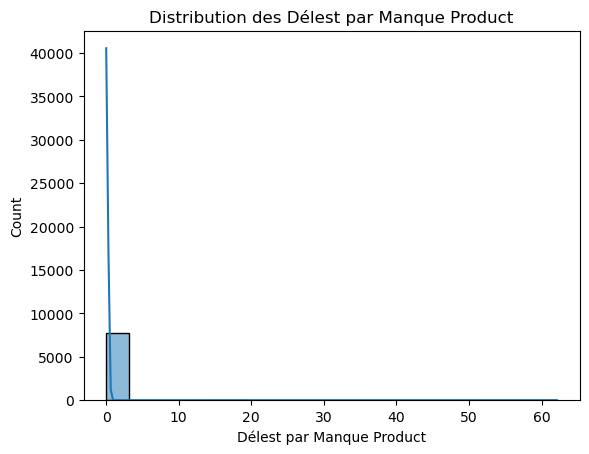

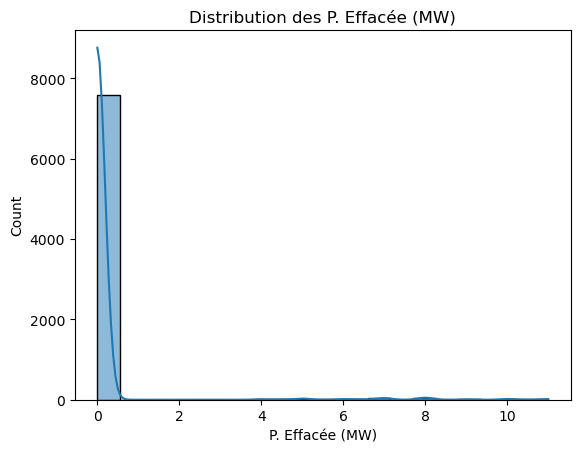

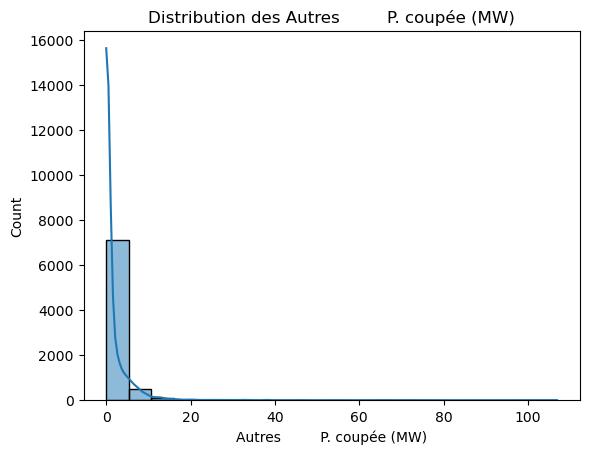

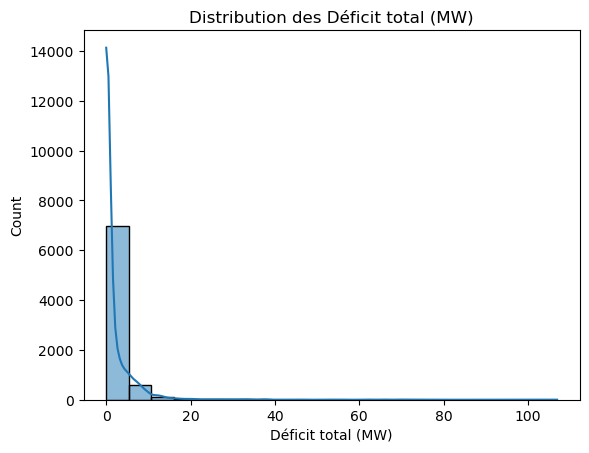

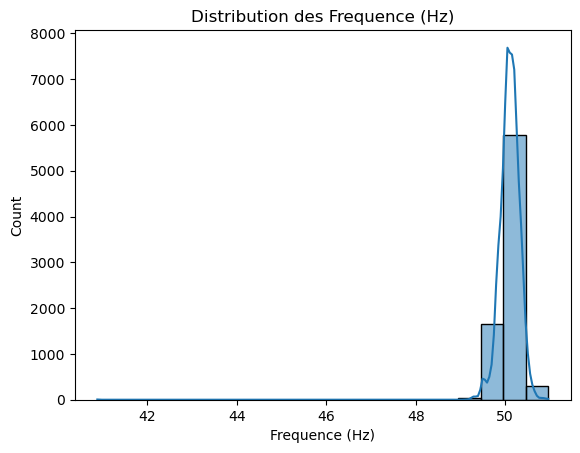

In [14]:
for i in Delestage.columns:
    sns.histplot(Delestage[i], bins=20, kde=True)
    plt.title(f"Distribution des {i}")
    plt.show()

In [15]:
# TRANSFORMATION DE LA DISTRIBUTION
Delestage_norm = pd.DataFrame({'P.dispo (MW)':Delestage['P.dispo (MW)'].values,
                               'Demande (MW)':Delestage['Demande (MW)'].values,
                               'Délest par Manque Product':np.log(Delestage['Délest par Manque Product'].values+1),
                               'P. Effacée (MW)':np.log(Delestage['P. Effacée (MW)'].values+1),
                               'Autres         P. coupée (MW)':np.log(Delestage['Autres         P. coupée (MW)'].values+1),
                               'Déficit total (MW)':np.log(Delestage['Déficit total (MW)'].values+1)
                               })

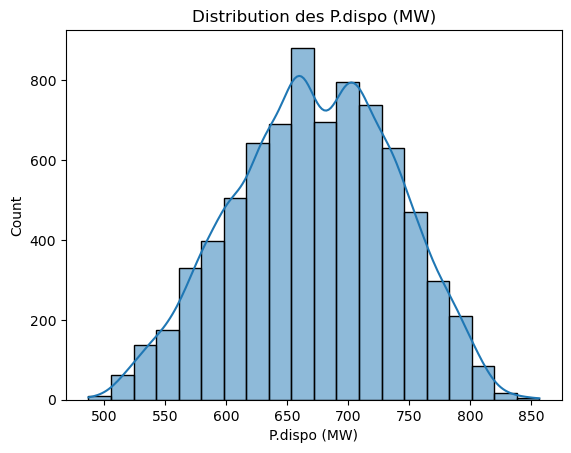

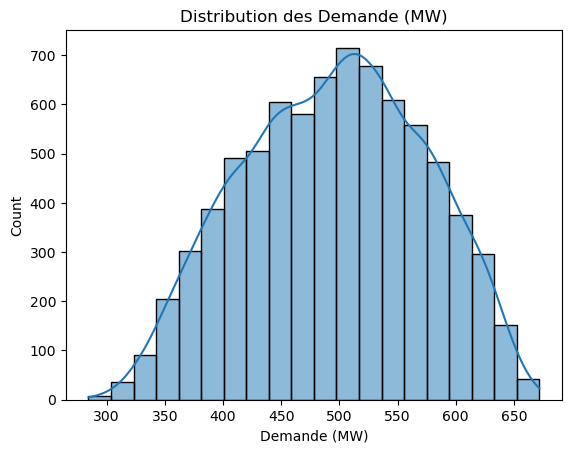

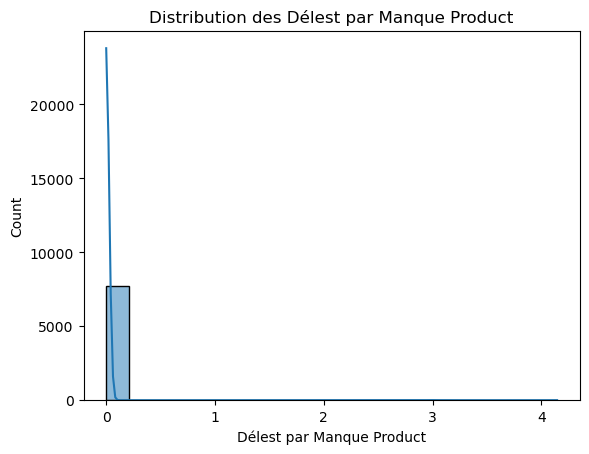

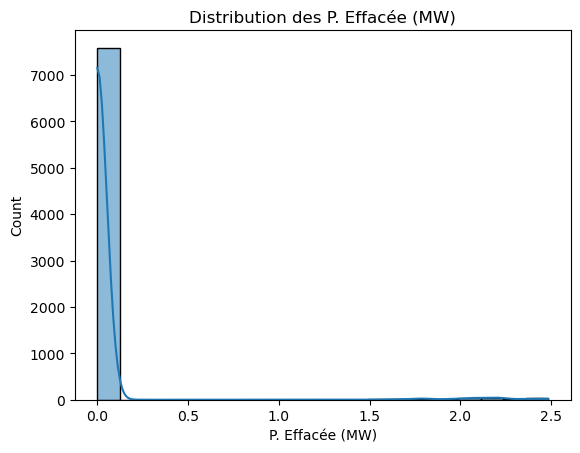

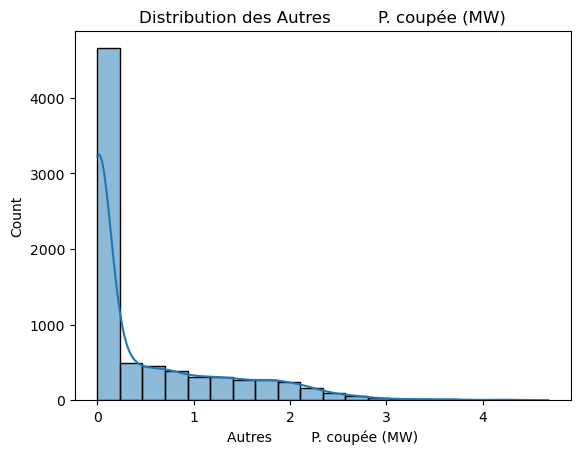

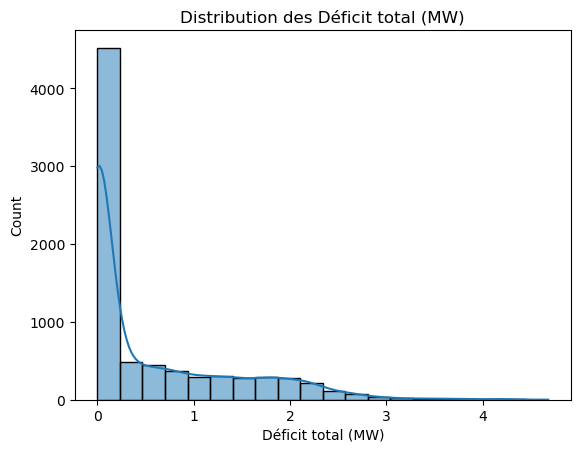

In [16]:
for i in Delestage.columns[:-1]:
    sns.histplot(Delestage_norm[i], bins=20, kde=True)
    plt.title(f"Distribution des {i}")
    plt.show()

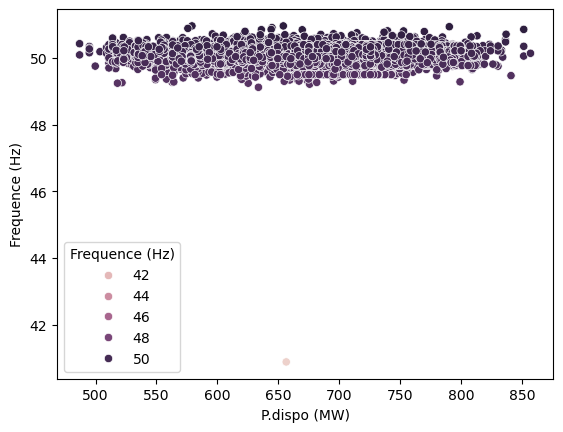

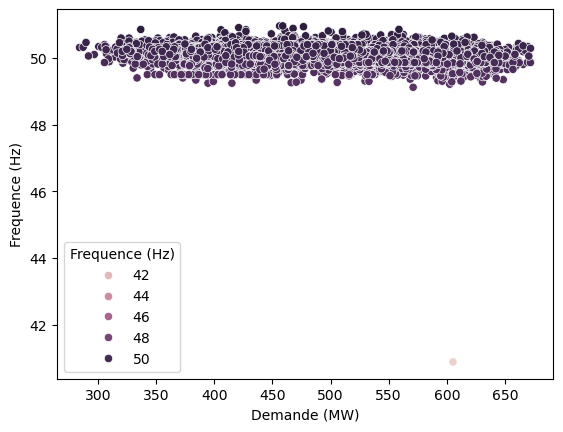

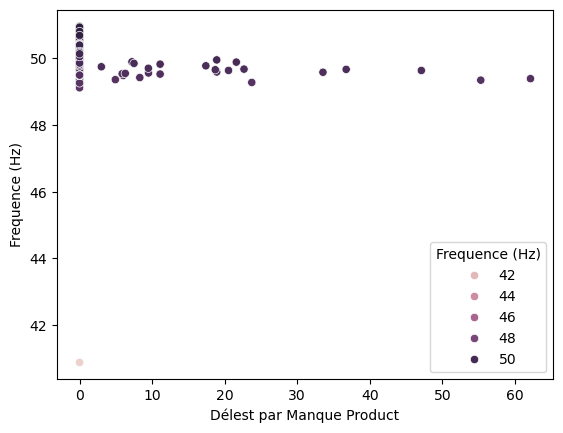

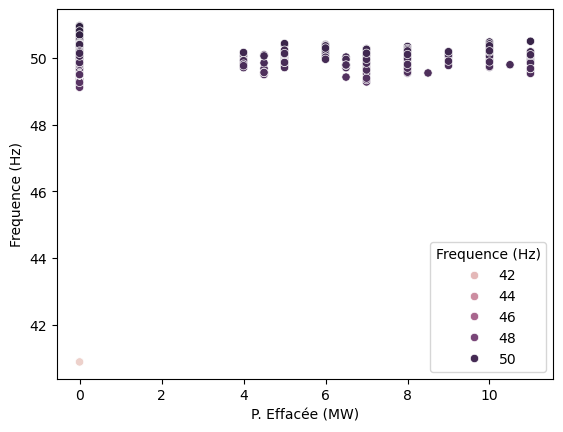

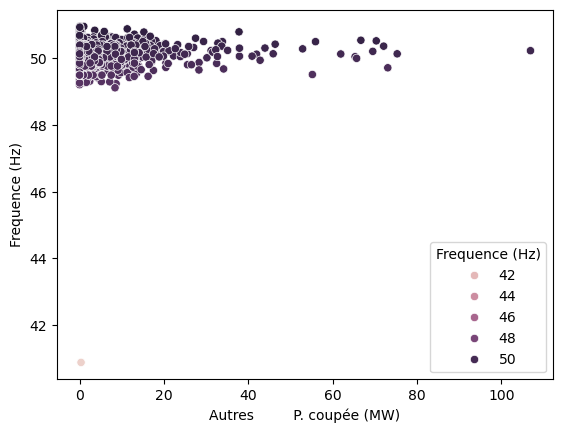

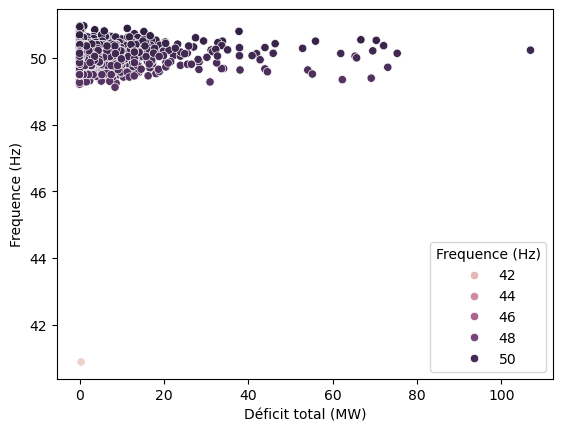

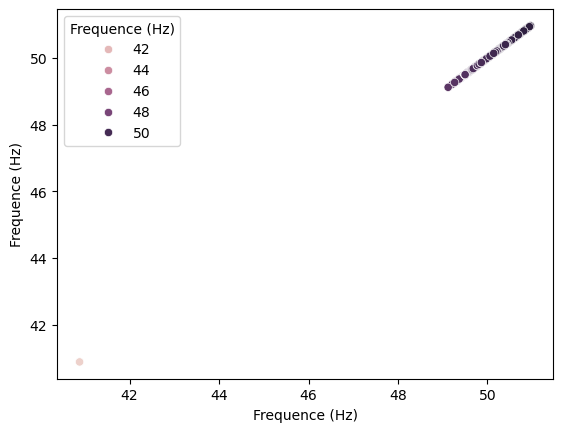

In [17]:
# Correction des valeurs aberantes et attepyque
for jj in Delestage[:-1]:
    sns.scatterplot(data=Delestage, x=jj, y='Frequence (Hz)', hue='Frequence (Hz)')
    plt.show()


### Visualition de la frequence

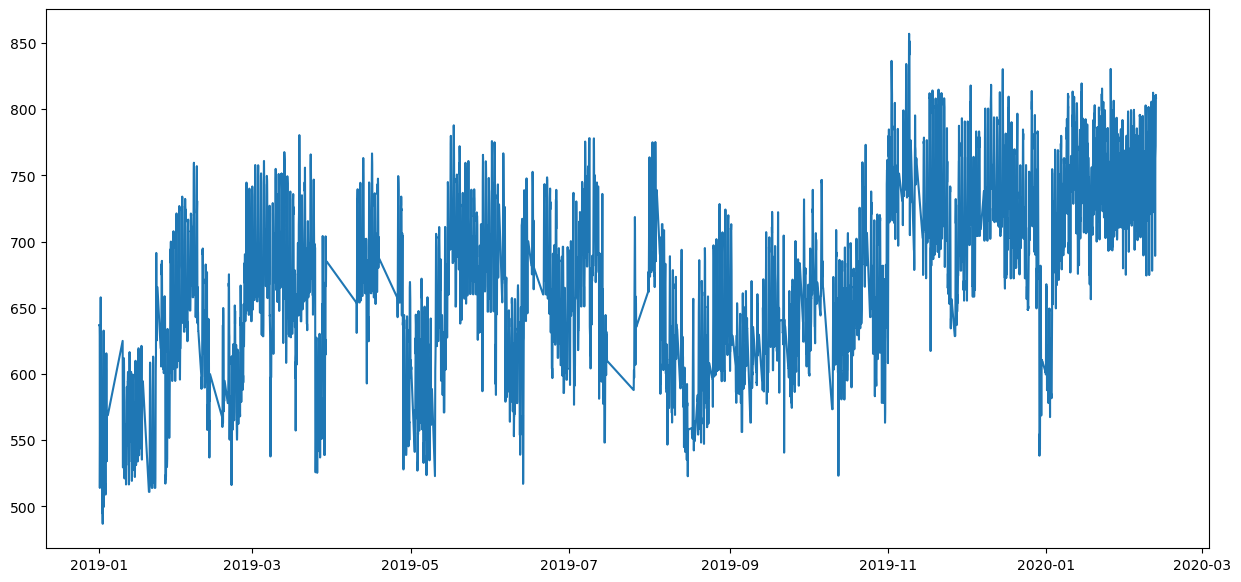

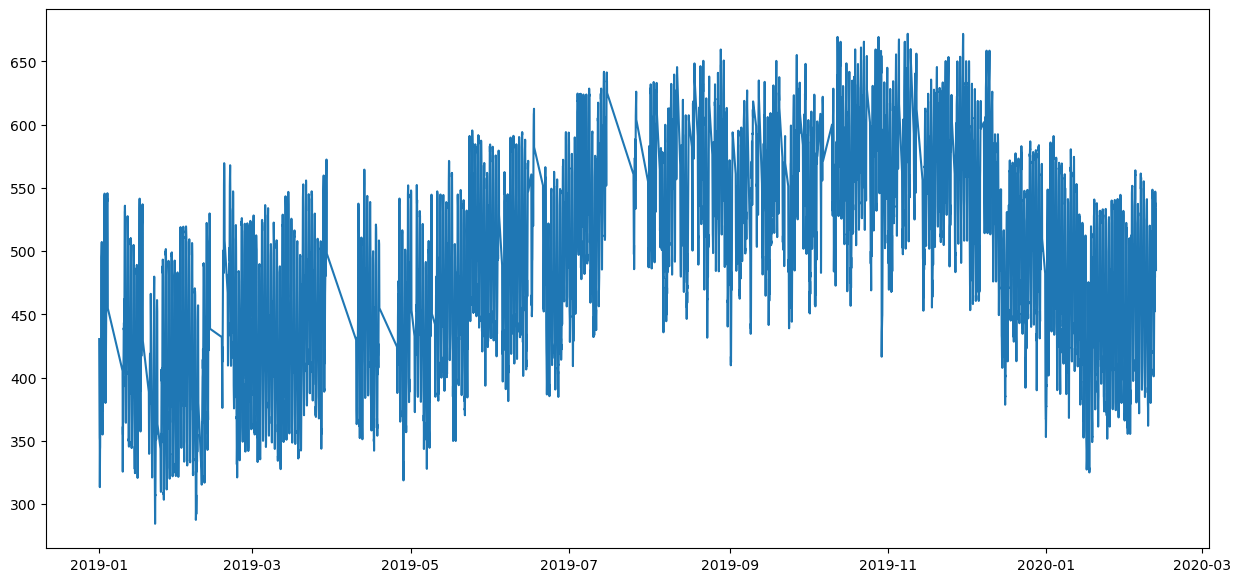

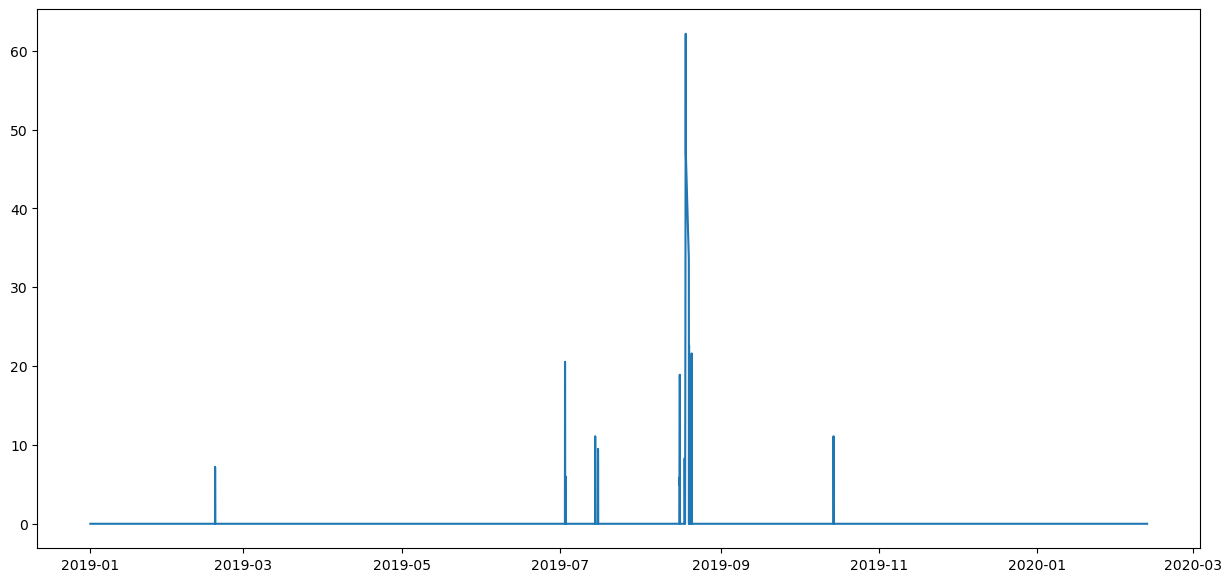

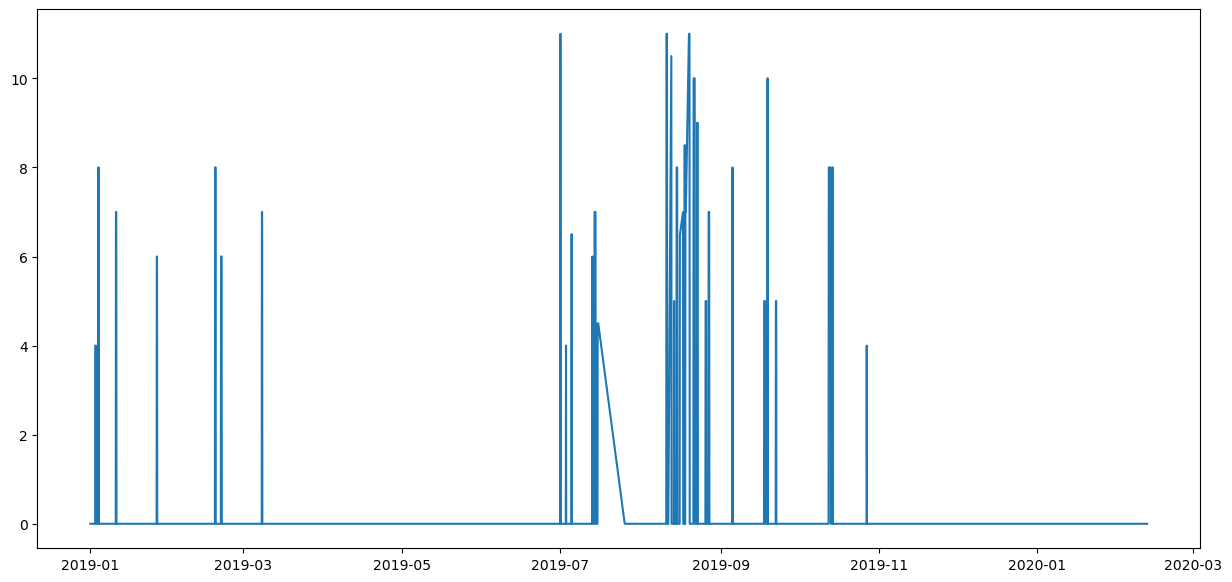

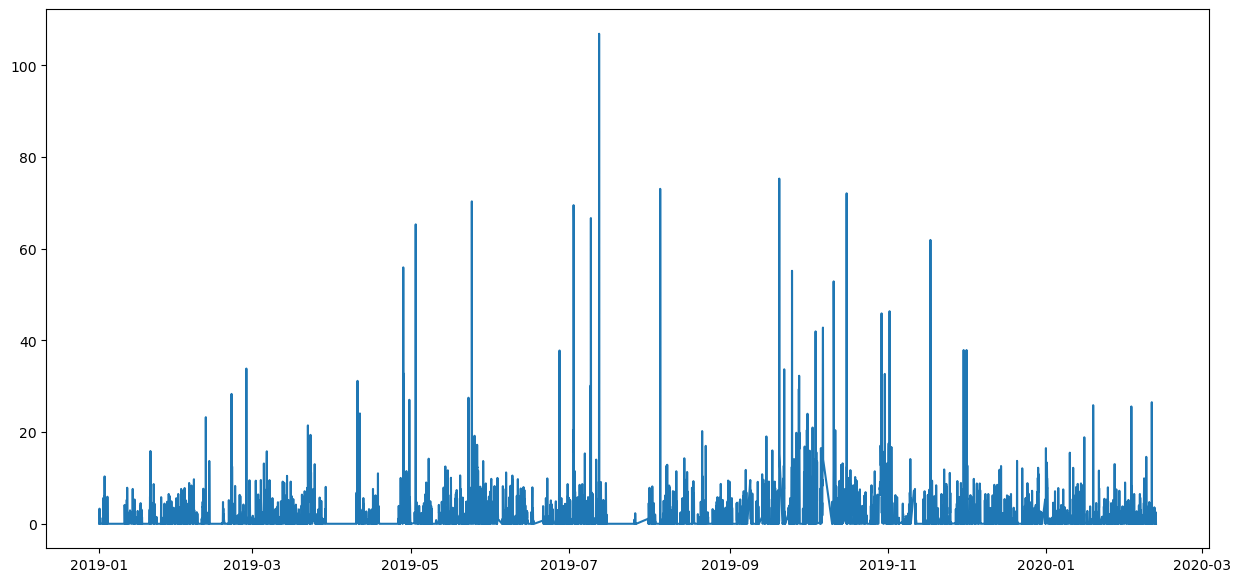

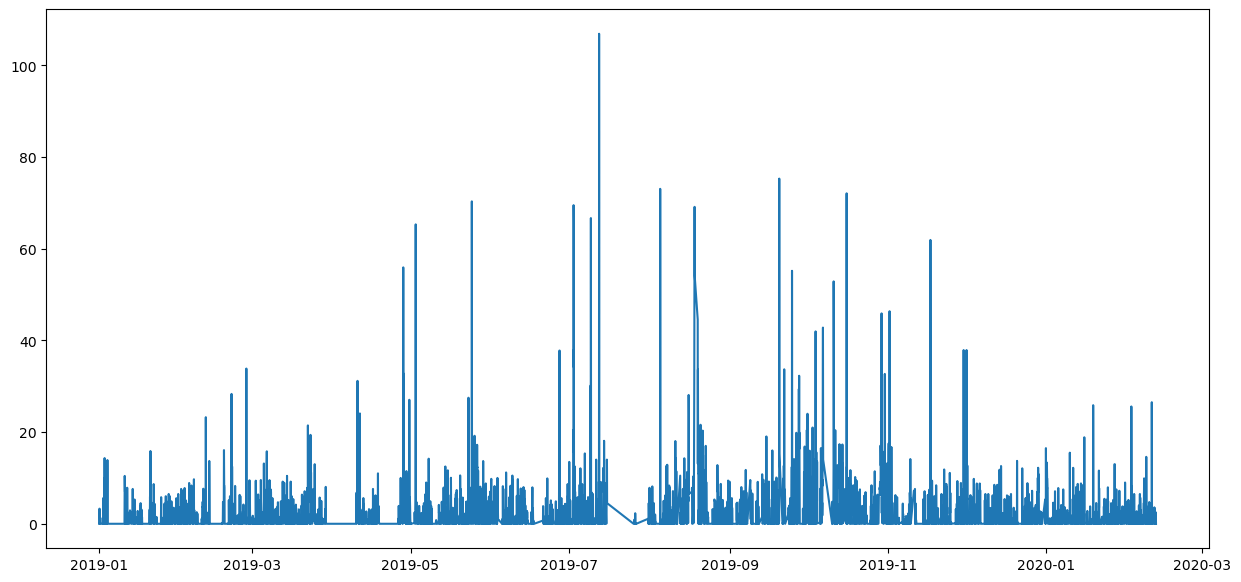

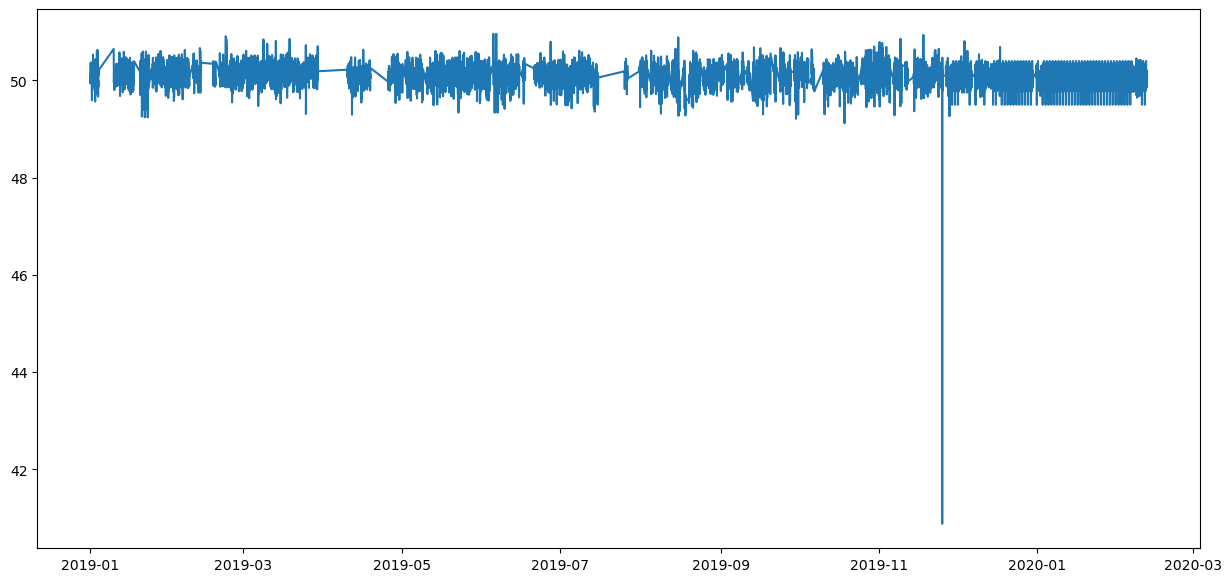

In [18]:
for jj in Delestage:
    plt.figure(figsize=(15,7))
    plt.subplot()
    plt.plot(Delestage[jj])
    plt.show()

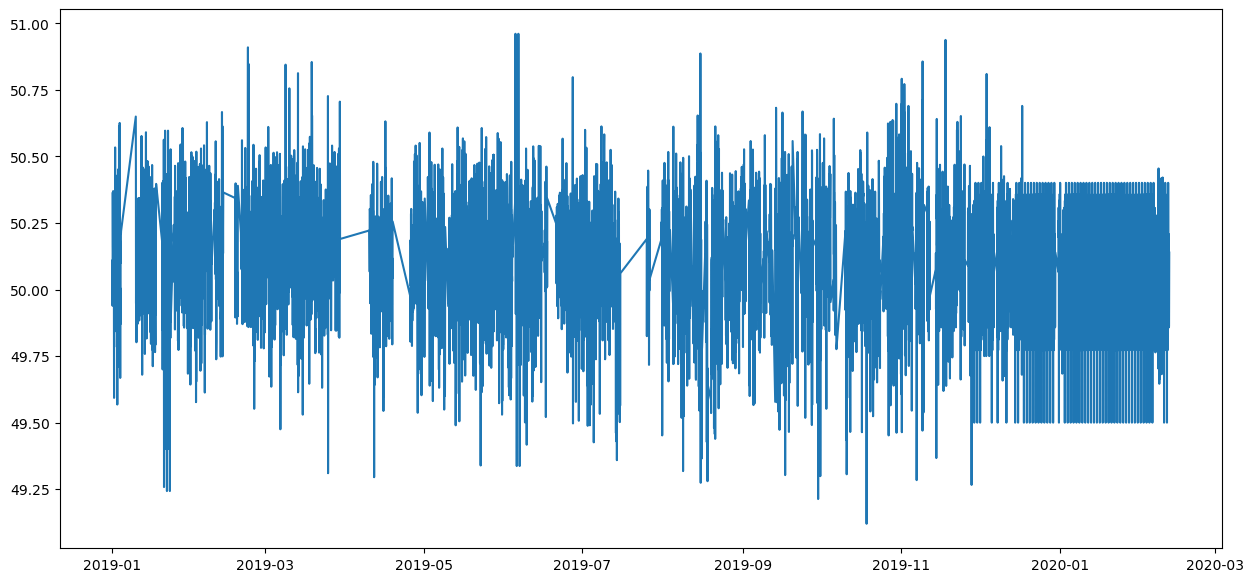

In [19]:
plt.figure(figsize=(15,7))
plt.plot(Delestage['Frequence (Hz)'][Delestage['Frequence (Hz)'] > 49])
plt.show()

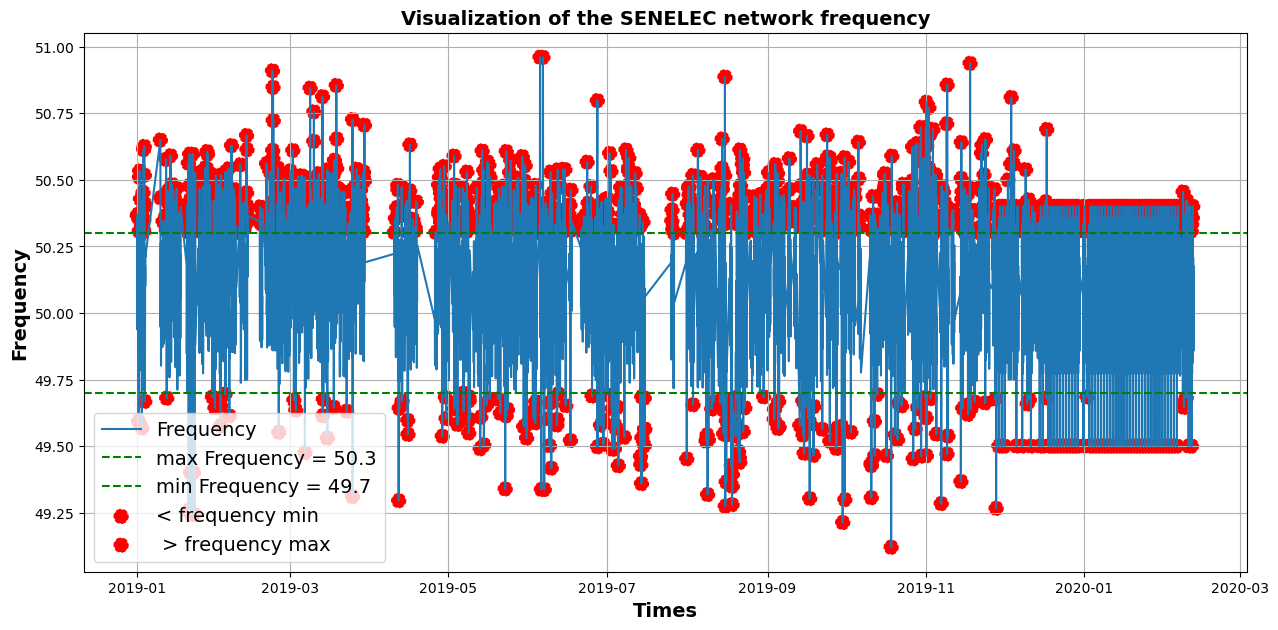

In [20]:
# elimination de la valeur attepique
limite = Delestage.loc[Delestage['Frequence (Hz)'] > 49]

# fixation des borne de l'intervalle de variation de la frequence 
y_max =50.3
y_min=49.7

# determination des valeurs de la frequence au dessous de la frequence inferieur
df_min = limite.loc[limite['Frequence (Hz)'] < y_min] 

# determination des valeurs de la frequence au dessus de la frequence superieur
df_max = limite.loc[limite['Frequence (Hz)'] > y_max] 

# Affichages des graphes
plt.figure(figsize=(15,7)) # fenetre graphique

plt.plot(limite['Frequence (Hz)'],label= 'Frequency') # visualisation de la frequence

plt.axhline(y_max,color="green", linestyle="--", label=f"max Frequency = {y_max}") # limites superieur

plt.axhline(y_min,color="green", linestyle="--", label=f"min Frequency = {y_min}") # limite inferieur

# visuation des valeurs hord de l'intervalle
plt.scatter(df_min.index, df_min['Frequence (Hz)'], color="red", label="< frequency min", s=100,linestyle="--")
plt.scatter(df_max.index, df_max['Frequence (Hz)'], color="red", label=" > frequency max", s=100,linestyle="--")

# Affichage
plt.legend(fontsize=14) # legende
plt.xlabel("Times",fontsize=14, fontweight="bold") # titre de l'axe absisses
plt.ylabel("Frequency",fontsize=14, fontweight="bold") # titre de l'axe des ordonnées
plt.title("Visualization of the SENELEC network frequency",fontsize=14, fontweight="bold") # titre du graphe
plt.grid() # gri
plt.show() # afficher

### Modelisation

In [21]:
Delestage.columns

Index(['P.dispo (MW)', 'Demande (MW)', 'Délest par Manque Product',
       'P. Effacée (MW)', 'Autres         P. coupée (MW)',
       'Déficit total (MW)', 'Frequence (Hz)'],
      dtype='object')

In [22]:
# 1. Separation des variables 
variables_explicatif = Delestage_norm.drop(columns=['Autres         P. coupée (MW)',])
"""Delestage.drop(columns=['Délest par Manque Product',
       'P. Effacée (MW)', 'Autres         P. coupée (MW)','Frequence (Hz)',
       'P. Effacée (MW)'],axis=1) # variables explicatifs
"""
frequence = Delestage[['Frequence (Hz)']] # variable cibre


# 2. Normalisation des données
scaler =MinMaxScaler() #StandardScaler()
variables_explicatif_scaled = scaler.fit_transform(variables_explicatif)
frequence_scaler = scaler.fit_transform(frequence)

# 3. Division des données en entraînement et test
variables_explicatif_scaled_train, variables_explicatif_scaled_test, frequence_train, frequence_test = train_test_split(
    variables_explicatif_scaled, frequence_scaler, test_size=0.2, random_state=42)


# 4. Modele de prediction
modele = LinearRegression();
modele.fit(variables_explicatif_scaled_train, frequence_train);


# 5. Prédictions de la frequence dans la base d'entrainement
frequency_pred = modele.predict(variables_explicatif_scaled_test);


# 6. Évaluation du modèle
mae = mean_absolute_error(frequence_test, frequency_pred)
rmse = root_mean_squared_error(frequence_test, frequency_pred)#, squared=True)
r2 = r2_score(frequence_test,frequency_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R² : {r2:.4f}")


MAE : 0.0164
RMSE : 0.0212
R² : 0.0324


In [23]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=20),
    "Lasso": Lasso(alpha=0.01)
}

for name, model in models.items():
    model.fit(variables_explicatif_scaled_train, frequence_train)
    score = model.score(variables_explicatif_scaled_test,frequence_test)
    print(f"{name} R²: {score:.3f}")


Linear R²: 0.032
Ridge R²: 0.034
Lasso R²: -0.000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


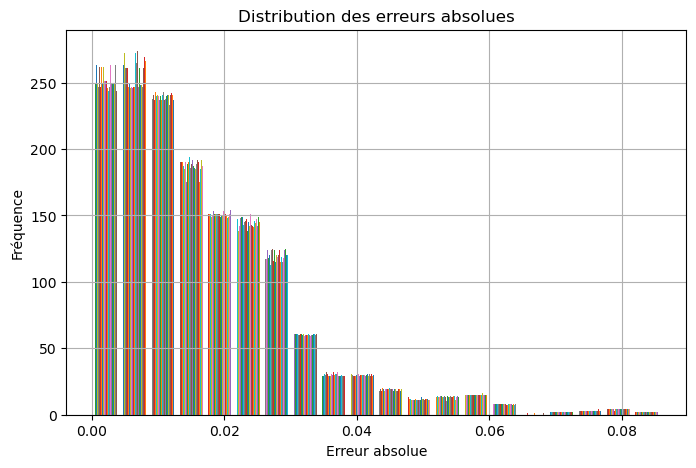

In [24]:
from sklearn.linear_model import PoissonRegressor

modelp = PoissonRegressor(alpha=1.0)
modelp.fit(variables_explicatif_scaled_train, frequence_train)
y_pred = modelp.predict(variables_explicatif_scaled_test)
pert = np.abs(y_pred-frequence_test)


plt.figure(figsize=(8, 5))
plt.hist(pert, bins=20)#, color='skyblue', edgecolor='black')
plt.title("Distribution des erreurs absolues")
plt.xlabel("Erreur absolue")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()


In [25]:
r2_score(y_pred,frequence_test)

-19492.613257770663

In [26]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
# 3. Créer un modèle KNN Regression avec k=5
knn_reg = KNeighborsRegressor(n_neighbors=5)

# 4. Entraîner le modèle
knn_reg.fit(variables_explicatif_scaled_train, frequence_train)

# 5. Prédire
y_pred = knn_reg.predict(variables_explicatif_scaled_test)

# 6. Évaluer
print("MSE :", root_mean_squared_error(frequence_test, y_pred))
print("R² score :", r2_score(frequence_test, y_pred))

# 7. Visualiser (si 1 seule feature)
plt.scatter(variables_explicatif_scaled_test,frequence_test, color='blue', label='Données réelles')
plt.scatter(variables_explicatif_scaled_test, y_pred, color='red', label='Prédictions')
plt.legend()
plt.title("Régression KNN")
plt.show()


MSE : 0.02309852648090027
R² score : -0.14738995898866825


ValueError: x and y must be the same size

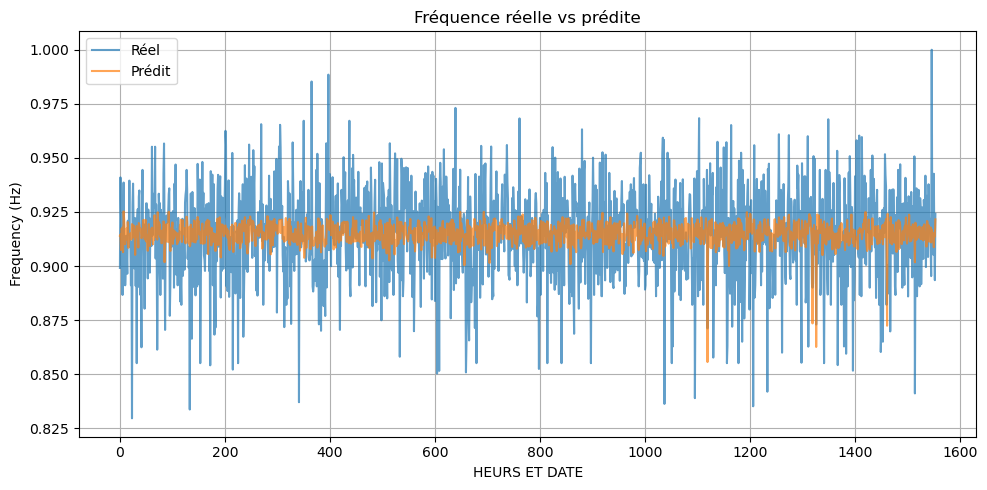

In [ ]:
# 12. Visualisation des résultats
plt.figure(figsize=(10, 5))
plt.plot(frequence_test, label="Réel", alpha=0.7)
plt.plot(frequency_pred, label="Prédit", alpha=0.7)
plt.title("Fréquence réelle vs prédite")
plt.xlabel("HEURS ET DATE")
plt.ylabel("Frequency (Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

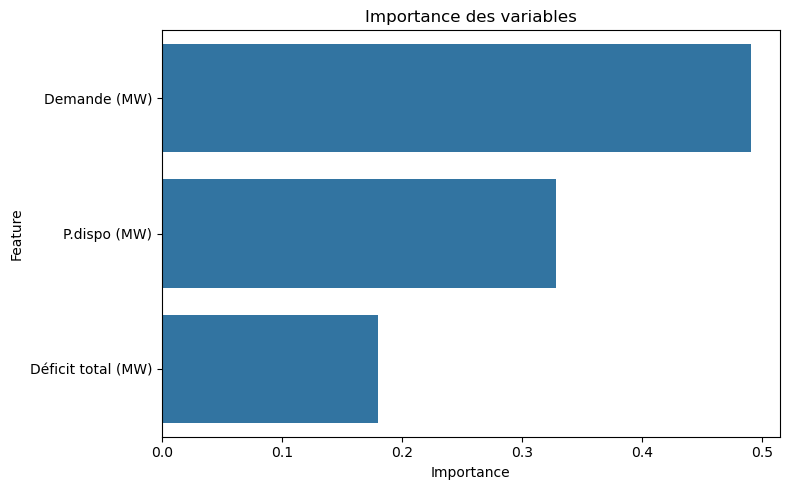

In [ ]:
# 13. Importance des variables
importances = modele.feature_importances_
features = variables_explicatif .columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Affichage
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Importance des variables")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Définir la grille de recherche
param_grid = {
    'n_estimators': [100, 200, 300, 500,1000],
    'max_depth': [None, 10, 20, 30, 40,500],
    'min_samples_split': [2, 5, 10,20],
    'min_samples_leaf': [1, 2, 4,5],
    'max_features': ['auto', 'sqrt'],
    'bootstrap': [True, False]
}

# Instancier le modèle
rf = RandomForestRegressor(random_state=42)

# Recherche aléatoire avec 30 combinaisons testées
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Exécuter la recherche
rf_random.fit(variables_explicatif_scaled_train, frequence_train)

# Meilleurs paramètres
print("Meilleurs paramètres trouvés :")
print(rf_random.best_params_)

# Évaluer le modèle optimisé
best_model = rf_random.best_estimator_
y_pred_optimized = best_model.predict(variables_explicatif_scaled_test)

# Affichage des scores
print("RMSE optimisé :", root_mean_squared_error(frequence_test, y_pred_optimized))#, squared=False))
print("R² optimisé :", r2_score(frequence_test, y_pred_optimized))


Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
65 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
56 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "c:\ProgramData\anaconda3\Lib\site-packages

Meilleurs paramètres trouvés :
{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
RMSE optimisé : 0.021434597335040693
R² optimisé : 0.011963128473378548


### Comparation des modeles de predictions

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Initialisation des modèles
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=10000, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=10000, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=10000, random_state=42)
}

# Dictionnaire pour stocker les performances
results = {}

# Entraînement et évaluation
for name, model in models.items():
    model.fit(variables_explicatif_scaled_train,frequence_train)
    y_pred = model.predict(variables_explicatif_scaled_test)
    
    mae = mean_absolute_error(frequence_test, y_pred)
    rmse = root_mean_squared_error(frequence_test, y_pred)
    r2 = r2_score(frequence_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

# Affichage des résultats
print("\n📊 Résultats des modèles ensemblistes :")
for name, metrics in results.items():
    print(f"\n{name}")
    print(f"MAE : {metrics['MAE']:.4f}")
    print(f"RMSE : {metrics['RMSE']:.4f}")
    print(f"R² : {metrics['R2']:.4f}")

# Voting Regressor (moyenne des prédictions)
voting = VotingRegressor([
    ('rf', models['Random Forest']),
    ('gbr', models['Gradient Boosting']),
    ('xgb', models['XGBoost'])
])
voting.fit(variables_explicatif_scaled_train,frequence_train)
y_pred_vote = voting.predict(variables_explicatif_scaled_test)

# Évaluer le VotingRegressor
print("\n🗳️ Voting Regressor")
print("MAE :", mean_absolute_error(frequence_test, y_pred_vote))
print("RMSE :", root_mean_squared_error(frequence_test, y_pred_vote))
print("R² :", r2_score(frequence_test, y_pred_vote))


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



📊 Résultats des modèles ensemblistes :

Random Forest
MAE : 0.0172
RMSE : 0.0225
R² : -0.0889

Gradient Boosting
MAE : 0.0189
RMSE : 0.0248
R² : -0.3276

XGBoost
MAE : 0.0192
RMSE : 0.0254
R² : -0.3827

AdaBoost
MAE : 0.0167
RMSE : 0.0215
R² : 0.0093


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_voting.py:694: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



🗳️ Voting Regressor
MAE : 0.017604904818420558
RMSE : 0.023126693026914887
R² : -0.15018993989109997
